
<div align="left">
    <img src="../assets/logo_evaliax.png" width="450"/>
</div>

# EVALIAX Tutorial: Explainable AI for Causal Forests

This notebook introduces **Explainable Artificial Intelligence (XAI)** techniques for interpreting heterogeneous treatment effects estimated with **Causal Forests**.

The tutorial is designed for PhD students and applied researchers interested in:

- causal machine learning,
- heterogeneous treatment effects (HTE),
- interpretable AI,
- and policy evaluation.

The notebook builds on recent advances in explainable causal machine learning and interpretable policy analytics.

Causal Forests provide flexible estimation of heterogeneous treatment effects ([Wager & Athey, 2018](https://doi.org/10.1080/01621459.2017.1319839)), while Explainable AI methods such as SHAP improve transparency and interpretability of machine learning models ([Lundberg & Lee, 2017](https://doi.org/10.48550/arXiv.1705.07874)).

Recent work also emphasizes the importance of interpretability and accountability in policy-oriented AI systems ([Rehill & Biddle, 2024](https://doi.org/10.48550/arXiv.2405.00000)).



# 1. Why explainability matters in causal machine learning

Causal Forests estimate heterogeneous treatment effects:

$$
\tau(X)=\mathbb{E}[Y(1)-Y(0)\mid X]
$$

However, the estimated treatment effects are often difficult to explain because the model is highly non-linear and data-driven.

Explainable AI techniques help answer questions such as:

- Which variables drive treatment heterogeneity?
- Why do some firms benefit more from the subsidy?
- Are the estimated effects economically plausible?
- Can policymakers trust the model?

Explainability is particularly important in public policy because causal estimates may directly influence:

- targeting decisions,
- resource allocation,
- and accountability mechanisms.



# 2. Import libraries


In [37]:

# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier
)

from econml.dml import CausalForestDML

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (7,5)



# 3. Load the dataset

We use the simulated subsidy dataset created in the previous notebook.

The dataset contains:

- firm characteristics,
- treatment assignment,
- post-treatment outcomes,
- and the ground-truth treatment effect.


In [38]:

# ==========================================================
# 2. LOAD DATASET
# ==========================================================

df = pd.read_csv(
    "../output/simulated_subsidy_dataset_with_causal_forest_results.csv"
)

print(df.head())
print("\nDataset shape:", df.shape)


   firm_id  size  age sector_code             sector_description  \
0        1    30   40           C                  Manufacturing   
1        2    18    1           J  Information and communication   
2        3    34    4           C                  Manufacturing   
3        4    68   30           J  Information and communication   
4        5    17   12           H     Transportation and storage   

   productivity  debt_ratio  profitability     region  aid_received  \
0     67.838397    0.357878       0.150633     Murcia             1   
1     60.008677    0.160489       0.068931    Galicia             0   
2     49.576732    0.054043       0.023460   Valencia             1   
3     70.464894    0.053263       0.105453  Andalusia             1   
4     59.938041    0.206822       0.060447     Madrid             1   

   p_treatment  grant_amount  log_grant_amount  true_effect  \
0     0.535370   5138.028620          8.544619     2.300506   
1     0.565620      0.000000          


# 4. Define outcome, treatment and covariates

## Outcome

We analyze:

- value added growth.

## Treatment

The treatment is binary:

$\displaystyle
T_i =
\\begin{cases}
1, & \\text{if firm } i \\text{ receives the subsidy} \\\\
0, & \\text{otherwise}
\\end{cases}
$

## Covariates

The covariates are measured before treatment assignment.


In [39]:

# ==========================================================
# 3. DEFINE Y, T AND X
# ==========================================================

Y = df["value_added_growth"]

T = df["aid_received"]

X = df[
    [
        "size",
        "age",
        "sector_code",
        "productivity",
        "debt_ratio",
        "profitability",
        "region"
    ]
]

X_encoded = pd.get_dummies(
    X,
    columns=["sector_code", "region"],
    drop_first=True
)



# 5. Train-test split


In [40]:

# ==========================================================
# 4. TRAIN-TEST SPLIT
# ==========================================================

X_train, X_test, Y_train, Y_test, T_train, T_test = train_test_split(
    X_encoded,
    Y,
    T,
    test_size=0.30,
    random_state=42
)



# 6. Nuisance models

Causal Forests rely on auxiliary models called nuisance models.

These models estimate:

## Outcome model

$$
m(X)=\\mathbb{E}[Y \\mid X]
$$

## Treatment model

$$
e(X)=P(T=1 \\mid X)
$$

The causal effect is estimated after orthogonalization and residualization.


In [41]:

# ==========================================================
# 5. NUISANCE MODELS
# ==========================================================

model_y = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

model_t = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)



# 7. Estimate the Causal Forest


In [42]:

# ==========================================================
# 6. CAUSAL FOREST
# ==========================================================

causal_forest = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    discrete_treatment=True,
    n_estimators=1000,
    min_samples_leaf=100,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

causal_forest.fit(
    Y_train,
    T_train,
    X=X_train
)



# 8. Estimate heterogeneous treatment effects

We estimate firm-level Conditional Average Treatment Effects (CATEs).


In [43]:

# ==========================================================
# 7. ESTIMATED TREATMENT EFFECTS
# ==========================================================

estimated_effect_test = causal_forest.effect(X_test)

print(estimated_effect_test[:10])


[2.4587941  2.49398424 2.77944311 2.36998074 2.80248439 2.47783
 3.55368068 2.49157243 3.28620586 3.47746794]


## 9. Calculating Variable Importance in the Causal Forest

Although the Causal Forest provides estimates of individual causal effects, or Conditional Average Treatment Effects (CATEs), it is also useful to understand which firm characteristics explain the heterogeneity observed in these effects.

The variable importance measure identifies those covariates that contribute most to splitting the sample into groups with different treatment effects. Unlike traditional predictive models, the importance of a variable in a Causal Forest does not reflect its ability to predict the outcome, but rather its relevance in explaining why the impact of the policy varies across firms.

This analysis allows us to address questions such as:

- Which firm characteristics best explain the effectiveness of the support program?
- Is the heterogeneity of effects mainly associated with industry sector, geographic location, or the firm’s financial situation?
- Which variables should be considered to improve the design and targeting of future public interventions?



In [ ]:

# ==========================================================
# VARIABLE IMPORTANCE
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": causal_forest.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Causal Forest Variable Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# 10. SHAP values for treatment heterogeneity

SHAP values decompose predictions into additive contributions from each feature.

The method is based on Shapley values from cooperative game theory and provides local explanations for machine learning predictions ([Lundberg & Lee, 2017](https://doi.org/10.48550/arXiv.1705.07874)).


In this context, SHAP helps explain:

- why some firms receive higher estimated treatment effects,
- which variables drive treatment heterogeneity,
- and how the Causal Forest behaves locally.


In [44]:
# ==========================================================
# SHAP EXPLAINER
# ==========================================================

# Convert all columns to numeric float
X_test_shap = X_test.astype(float)

# Optional: use a smaller background sample to make SHAP faster
background = shap.sample(
    X_test_shap,
    100,
    random_state=42
)

explainer = shap.Explainer(
    causal_forest.effect,
    background
)

shap_values = explainer(X_test_shap)

PermutationExplainer explainer: 1501it [16:34,  1.49it/s]                          


/var/folders/w3/_qb6hmvs2cx8d_1d5m6snq980000gn/T/ipykernel_22348/1082176579.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


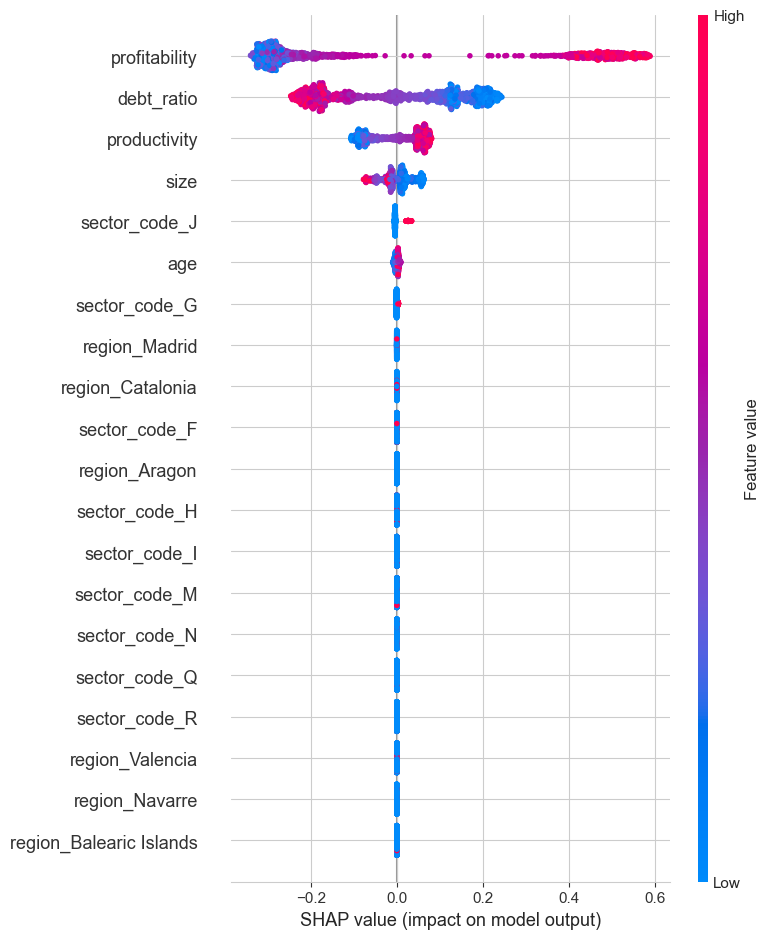

In [45]:

# ==========================================================
# SHAP SUMMARY PLOT
# ==========================================================

shap.summary_plot(

    shap_values,

    X_test_shap

)


# Interpretation

Variables appearing at the top of the graph contribute most strongly to treatment heterogeneity.

The colors indicate the value of the feature:

- red → high values,
- blue → low values.

The horizontal position reflects the contribution of the variable to the estimated treatment effect.



Dependence plots help visualize how a specific variable affects the estimated treatment effect.


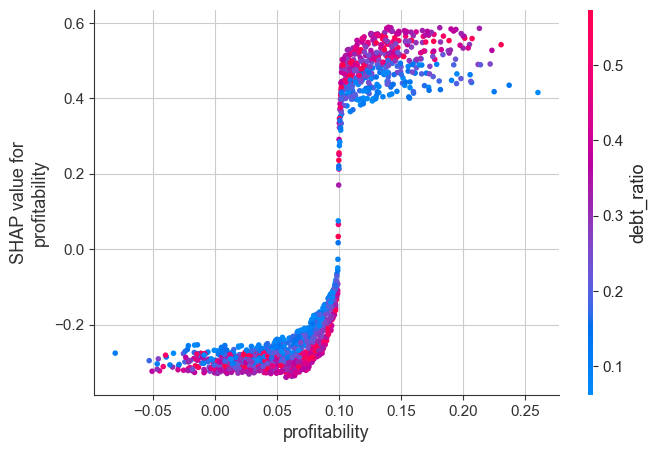

In [46]:

# ==========================================================
#  SHAP DEPENDENCE PLOT
# ==========================================================

shap.dependence_plot(
    "profitability",
    shap_values.values,
    X_test
)



# Interpretation

The dependence plot illustrates:

- whether treatment effects increase or decrease with productivity,
- potential non-linearities,
- and interaction patterns captured by the Causal Forest.



# Local explanations

SHAP can also explain treatment effects at the individual firm level.

This improves transparency and accountability because policymakers can inspect why a specific firm receives a high or low estimated treatment effect.


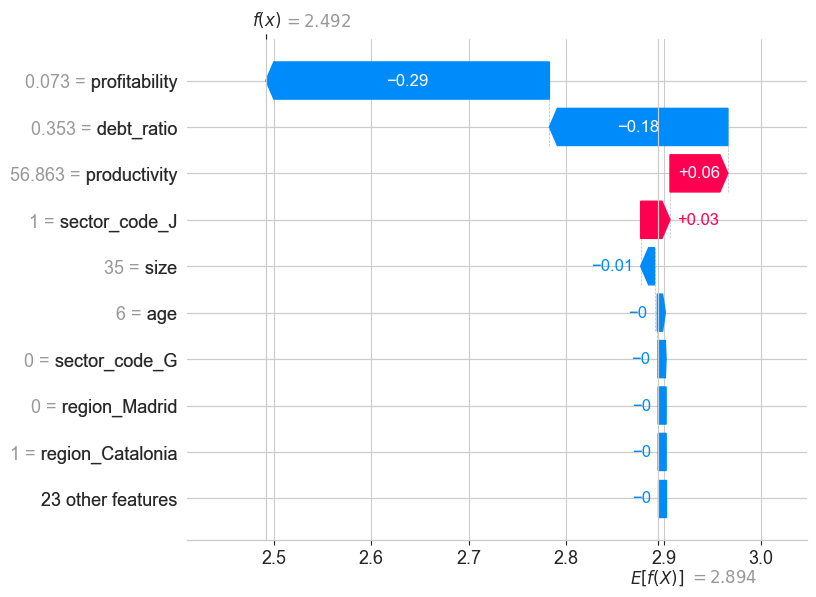

In [47]:

# ==========================================================
#  LOCAL EXPLANATION
# ==========================================================

shap.plots.waterfall(
    shap_values[7]
)



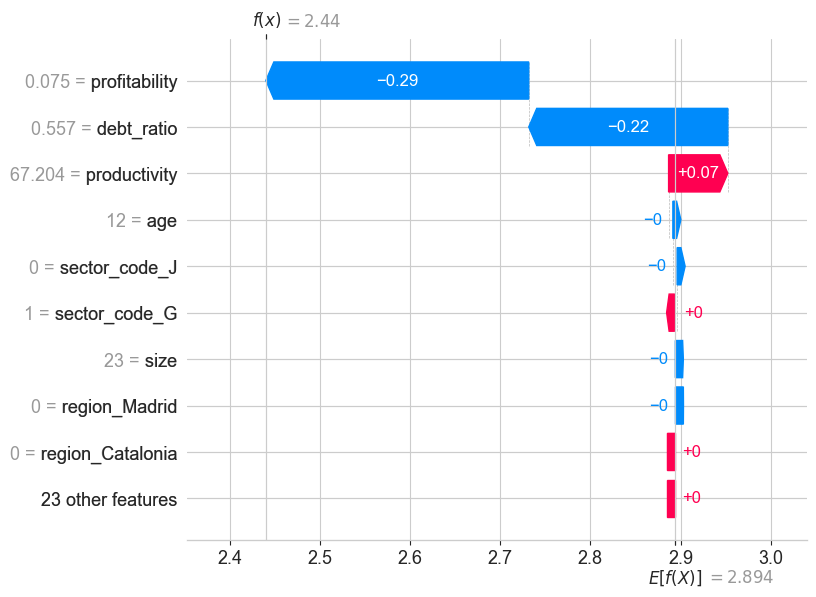

In [48]:
# ==========================================================
# LOCAL EXPLANATION - VALENCIAN COMPANY
# ==========================================================

valencia_positions = np.where(
    X_test["region_Valencia"] == 1
)[0]

selected_pos = valencia_positions[0]

shap.plots.waterfall(
    shap_values[selected_pos]
)

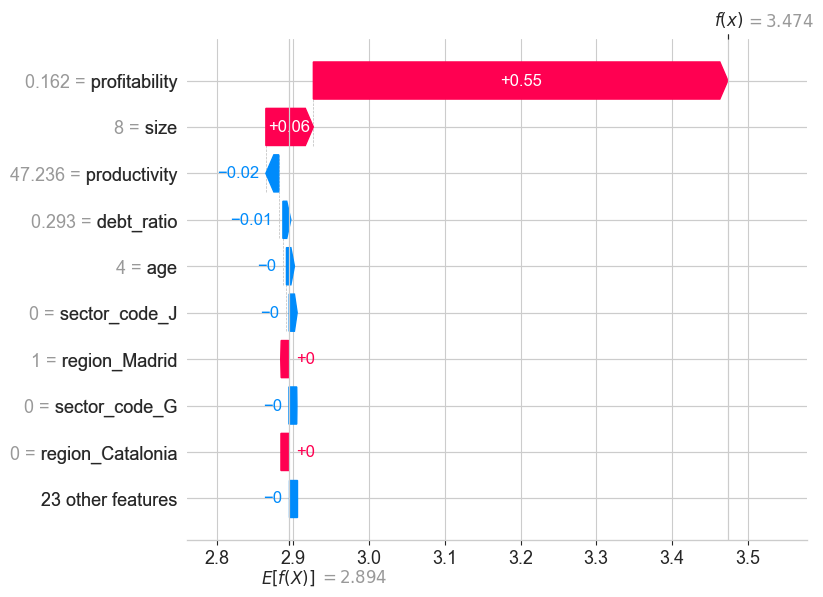

In [49]:
# ==========================================================
# LOCAL EXPLANATION - MADRID COMPANY
# ==========================================================
valencia_positions = np.where(
    X_test["region_Madrid"] == 1
)[0]

selected_pos = valencia_positions[0]

shap.plots.waterfall(
    shap_values[selected_pos]
)


# Interpretation

The waterfall plot decomposes the estimated treatment effect into additive contributions from each feature.

Positive contributions increase the estimated treatment effect, while negative contributions reduce it.


,feature,importance
4,profitability,6.365819e-01
3,debt_ratio,2.197452e-01
2,productivity,6.813623e-02
0,size,4.073777e-02
9,sector_code_J,1.861463e-02
1,age,1.365314e-02
6,sector_code_G,2.484532e-03
27,region_Madrid,4.659426e-05
22,region_Catalonia,4.673485e-08
30,region_Navarre,0.000000e+00


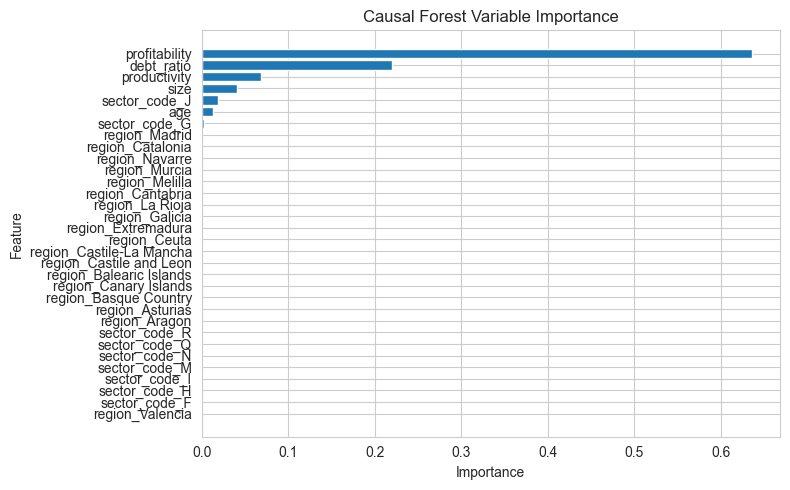


#  Main conclusions

This notebook illustrated how Explainable AI techniques can improve transparency in causal machine learning.

The tutorial demonstrated:

- Causal Forest estimation,
- SHAP-based interpretability,
- local and global explanations,
- and heterogeneity analysis across sectors and regions.

Explainable AI is particularly valuable in policy evaluation because it supports:

- transparency,
- accountability,
- and trustworthy AI systems.
